# AstroLogics Tutorial: Boolean Network Analysis and Clustering (Big model)

This tutorial demonstrates the AstroLogics framework for analyzing and comparing Boolean network model ensembles. AstroLogics is designed for benchmarking Boolean models through three major evaluation criteria: network evaluation, logical function evaluation, and dynamic evaluation.

## Overview of AstroLogics Framework

AstroLogics addresses a critical gap in Boolean network modeling: while multiple methods exist for Boolean model synthesis (like Bonesis, BN-sketch), there hasn't been a standardized way to evaluate and compare generated model ensembles. The framework focuses on:

- **Dynamic properties**: Examining state transition graphs and model behaviors through simulation
- **Logical function evaluation**: Analyzing and comparing logical rules that govern node behaviors
- **Model clustering**: Identifying groups of models with similar dynamics and logical features

## Required Libraries

In [ ]:
import pandas as pd 
import os
import sys
sys.path.append('../../src')
import astrologics as ast
import seaborn as sns
import matplotlib.pyplot as plt

### Dataset: Cancer Invasion model

We'll use the Cancer Invasion model, which is more complex than the CNS differentiation model. This model contains 32 nodes with extensive connectivity and demonstrates key regulatory mechanisms involved in cancer cell invasion and metastasis. The model incorporates signaling pathways related to EMT (Epithelial-Mesenchymal Transition), cell adhesion, and extracellular matrix degradation.

This model has been used to demonstrate the capability of Bonesis and to introduce the concept of Boolean model ensembles, as described [here](https://doi.org/10.1007/978-3-030-60327-4_11).

## Step 1: Load Model Ensemble

In [ ]:
model_path = '../../inferred_big_model/Signaling in Macrophage Activation_18433497/'
model = ast.ensemble(model_path, project_name = 'big_model')
model.create_simulation()

Simulation object created


The `ensemble` object is the core component of AstroLogics that handles:

- Loading multiple Boolean network models from a directory
- Managing simulation parameters and configurations
- Coordinating analysis across the model ensemble

## Step 2: Simulate the model ensemble

In this part of the script, we first simulate all BNs within the model ensemble. We use the MaBoSS engine as the main simulator.

The use of MaBoSS also allows us to define different initial states for the simulation. We first examine the initial states described in Chevalier & Noel et al., 2020.

In [8]:
# Read network structure and set initial conditions
test = pd.read_csv(model_path + 'bn_0.bnet', sep = ',', header = None)
test[1] = 0.5  # Set all nodes to 0.5 probability initially
test_dict = dict(zip(test[0], test[1]))

This creates an initial state where all nodes have equal probability (0.5) of being active. This represents a neutral starting condition that allows the system to evolve according to its inherent dynamics.

We then start the simulation using MaBoSS.

**MaBoSS** (Markovian Boolean Stochastic Simulator) is crucial for the AstroLogics approach because:

- It converts Boolean network dynamics into continuous-time Markov processes
- Provides probabilistic approximation of complex state transition graphs
- Enables analysis of both transient and steady-state behaviors
- Scales computationally better than exhaustive state space exploration

Simulation takes about 16 minutes (20-core 12th Gen Intel® Core™ i7-12700H × 20).

We therefore added the simulated file in `tmp` (named `Invasion_simulation_random.csv`), which can be loaded directly into `model.simulation.simulation_df`.

In [ ]:
# Configure simulation parameters
#model.simulation.update_parameters(max_time = 20,thread_count = 15, sample_count = 2000)
#model.simulation.run_simulation(initial_state=test_dict)
#model.simulation.simulation_df.to_csv('data/precomputed_Invasion_simulation_random.csv')

# Load the simulation results
model.simulation.simulation_df = pd.read_csv('../../data/simulation_files/Signaling in Macrophage Activation_18433497_simulation.csv', index_col=0)

## Step 3: Calculate trajectories and visualize the distance matrix using MDS

In this part of the script, we compare two methods for calculating distances between models.

In the `calculate_distancematrix` function, users can select one of two data options for distance calculation.

- `endpoint`: Uses node activation probabilities at the endpoint of the MaBoSS simulation. Users can also define the `timepoint` parameter to calculate distance at a specific timepoint.
- `trajectory`: Uses the full MaBoSS simulation trajectory and the `dtw` method to calculate distances between models.

Here, we show different results that can be obtained from these two methods.
- Using `endpoint`, we observed no clear separation of models, which corresponds to the single attractor that all models can reach.
- In contrast, using `trajectory`, we observed two major clusters of models based on the different signaling paths taken by the two BN groups.


In [10]:
model.create_trajectory()

Trajectory object created


Calculating distance matrix for whole trajectory...


  0%|          | 0/1000 [00:00<?, ?it/s]

Distance matrix calculated successfully.


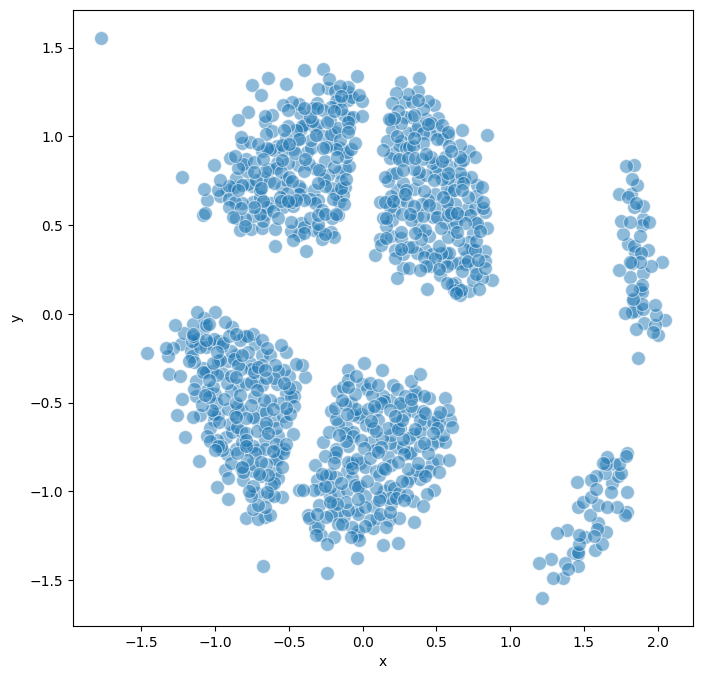

In [11]:
model.trajectory.calculate_distancematrix(mode = 'trajectory')
# Perform MDS (Multidimensional Scaling) for visualization
model.trajectory.calculate_MDS(random_state=12345)
model.trajectory.plot_MDS(s = 100, fig_size = (8,8))

In [18]:
model.trajectory.pca_df

,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,pc10,model_id,timepoint,kmean_cluster
0,-6.189809,2.802768,-0.816479,0.259297,0.062953,0.007561,-0.056227,-0.064930,0.067322,0.047089,bn_411,0.0,0
1,-5.520238,1.012777,0.311394,-0.399434,0.055948,0.023540,0.176070,-0.120329,0.124763,0.049663,bn_411,1.0,0
2,-4.379146,-0.500155,0.702569,-0.328646,0.114314,0.041178,0.010674,-0.152449,0.115676,0.096197,bn_411,2.0,0
3,-3.171592,-1.406320,0.576999,-0.033372,0.198472,0.087212,-0.088356,-0.134240,0.090430,0.066329,bn_411,3.0,0
4,-2.044360,-1.803891,0.196612,0.175217,0.219920,0.091954,-0.039205,-0.090830,0.061453,0.040007,bn_411,4.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2.080042,0.703362,0.256317,0.073099,0.006994,0.000461,0.001960,-0.000314,0.000834,0.000465,bn_588,15.0,0
19996,2.098040,0.743046,0.306025,0.116468,0.014429,-0.001455,0.028416,0.003304,-0.000321,0.002101,bn_588,16.0,0
19997,2.108337,0.767667,0.338878,0.145269,0.019148,-0.003479,0.045135,0.005608,-0.000984,0.004553,bn_588,17.0,0
19998,2.114461,0.782218,0.357869,0.161293,0.022665,-0.004566,0.052791,0.006608,-0.001331,0.004147,bn_588,18.0,0


In [41]:
model.trajectory.pca_trajectory()
pca_traj = model.trajectory.pca_df

In [42]:
pca_traj

,pc1,pc2,pc3,pc4,pc5,pc6,pc7,pc8,pc9,pc10,model_id,timepoint
0,-6.189809,2.802768,-0.816479,0.259297,0.062953,0.007561,-0.056227,-0.064930,0.067322,0.047089,bn_411,0.0
1,-5.520238,1.012777,0.311394,-0.399434,0.055948,0.023540,0.176070,-0.120329,0.124763,0.049663,bn_411,1.0
2,-4.379146,-0.500155,0.702569,-0.328646,0.114314,0.041178,0.010674,-0.152449,0.115676,0.096197,bn_411,2.0
3,-3.171592,-1.406320,0.576999,-0.033372,0.198472,0.087212,-0.088356,-0.134240,0.090430,0.066329,bn_411,3.0
4,-2.044360,-1.803891,0.196612,0.175217,0.219920,0.091954,-0.039205,-0.090830,0.061453,0.040007,bn_411,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2.080042,0.703362,0.256317,0.073099,0.006994,0.000461,0.001960,-0.000314,0.000834,0.000465,bn_588,15.0
19996,2.098040,0.743046,0.306025,0.116468,0.014429,-0.001455,0.028416,0.003304,-0.000321,0.002101,bn_588,16.0
19997,2.108337,0.767667,0.338878,0.145269,0.019148,-0.003479,0.045135,0.005608,-0.000984,0.004553,bn_588,17.0
19998,2.114461,0.782218,0.357869,0.161293,0.022665,-0.004566,0.052791,0.006608,-0.001331,0.004147,bn_588,18.0


/tmp/ipykernel_137349/1493818583.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_id, group in pca_traj.groupby('model_id'):


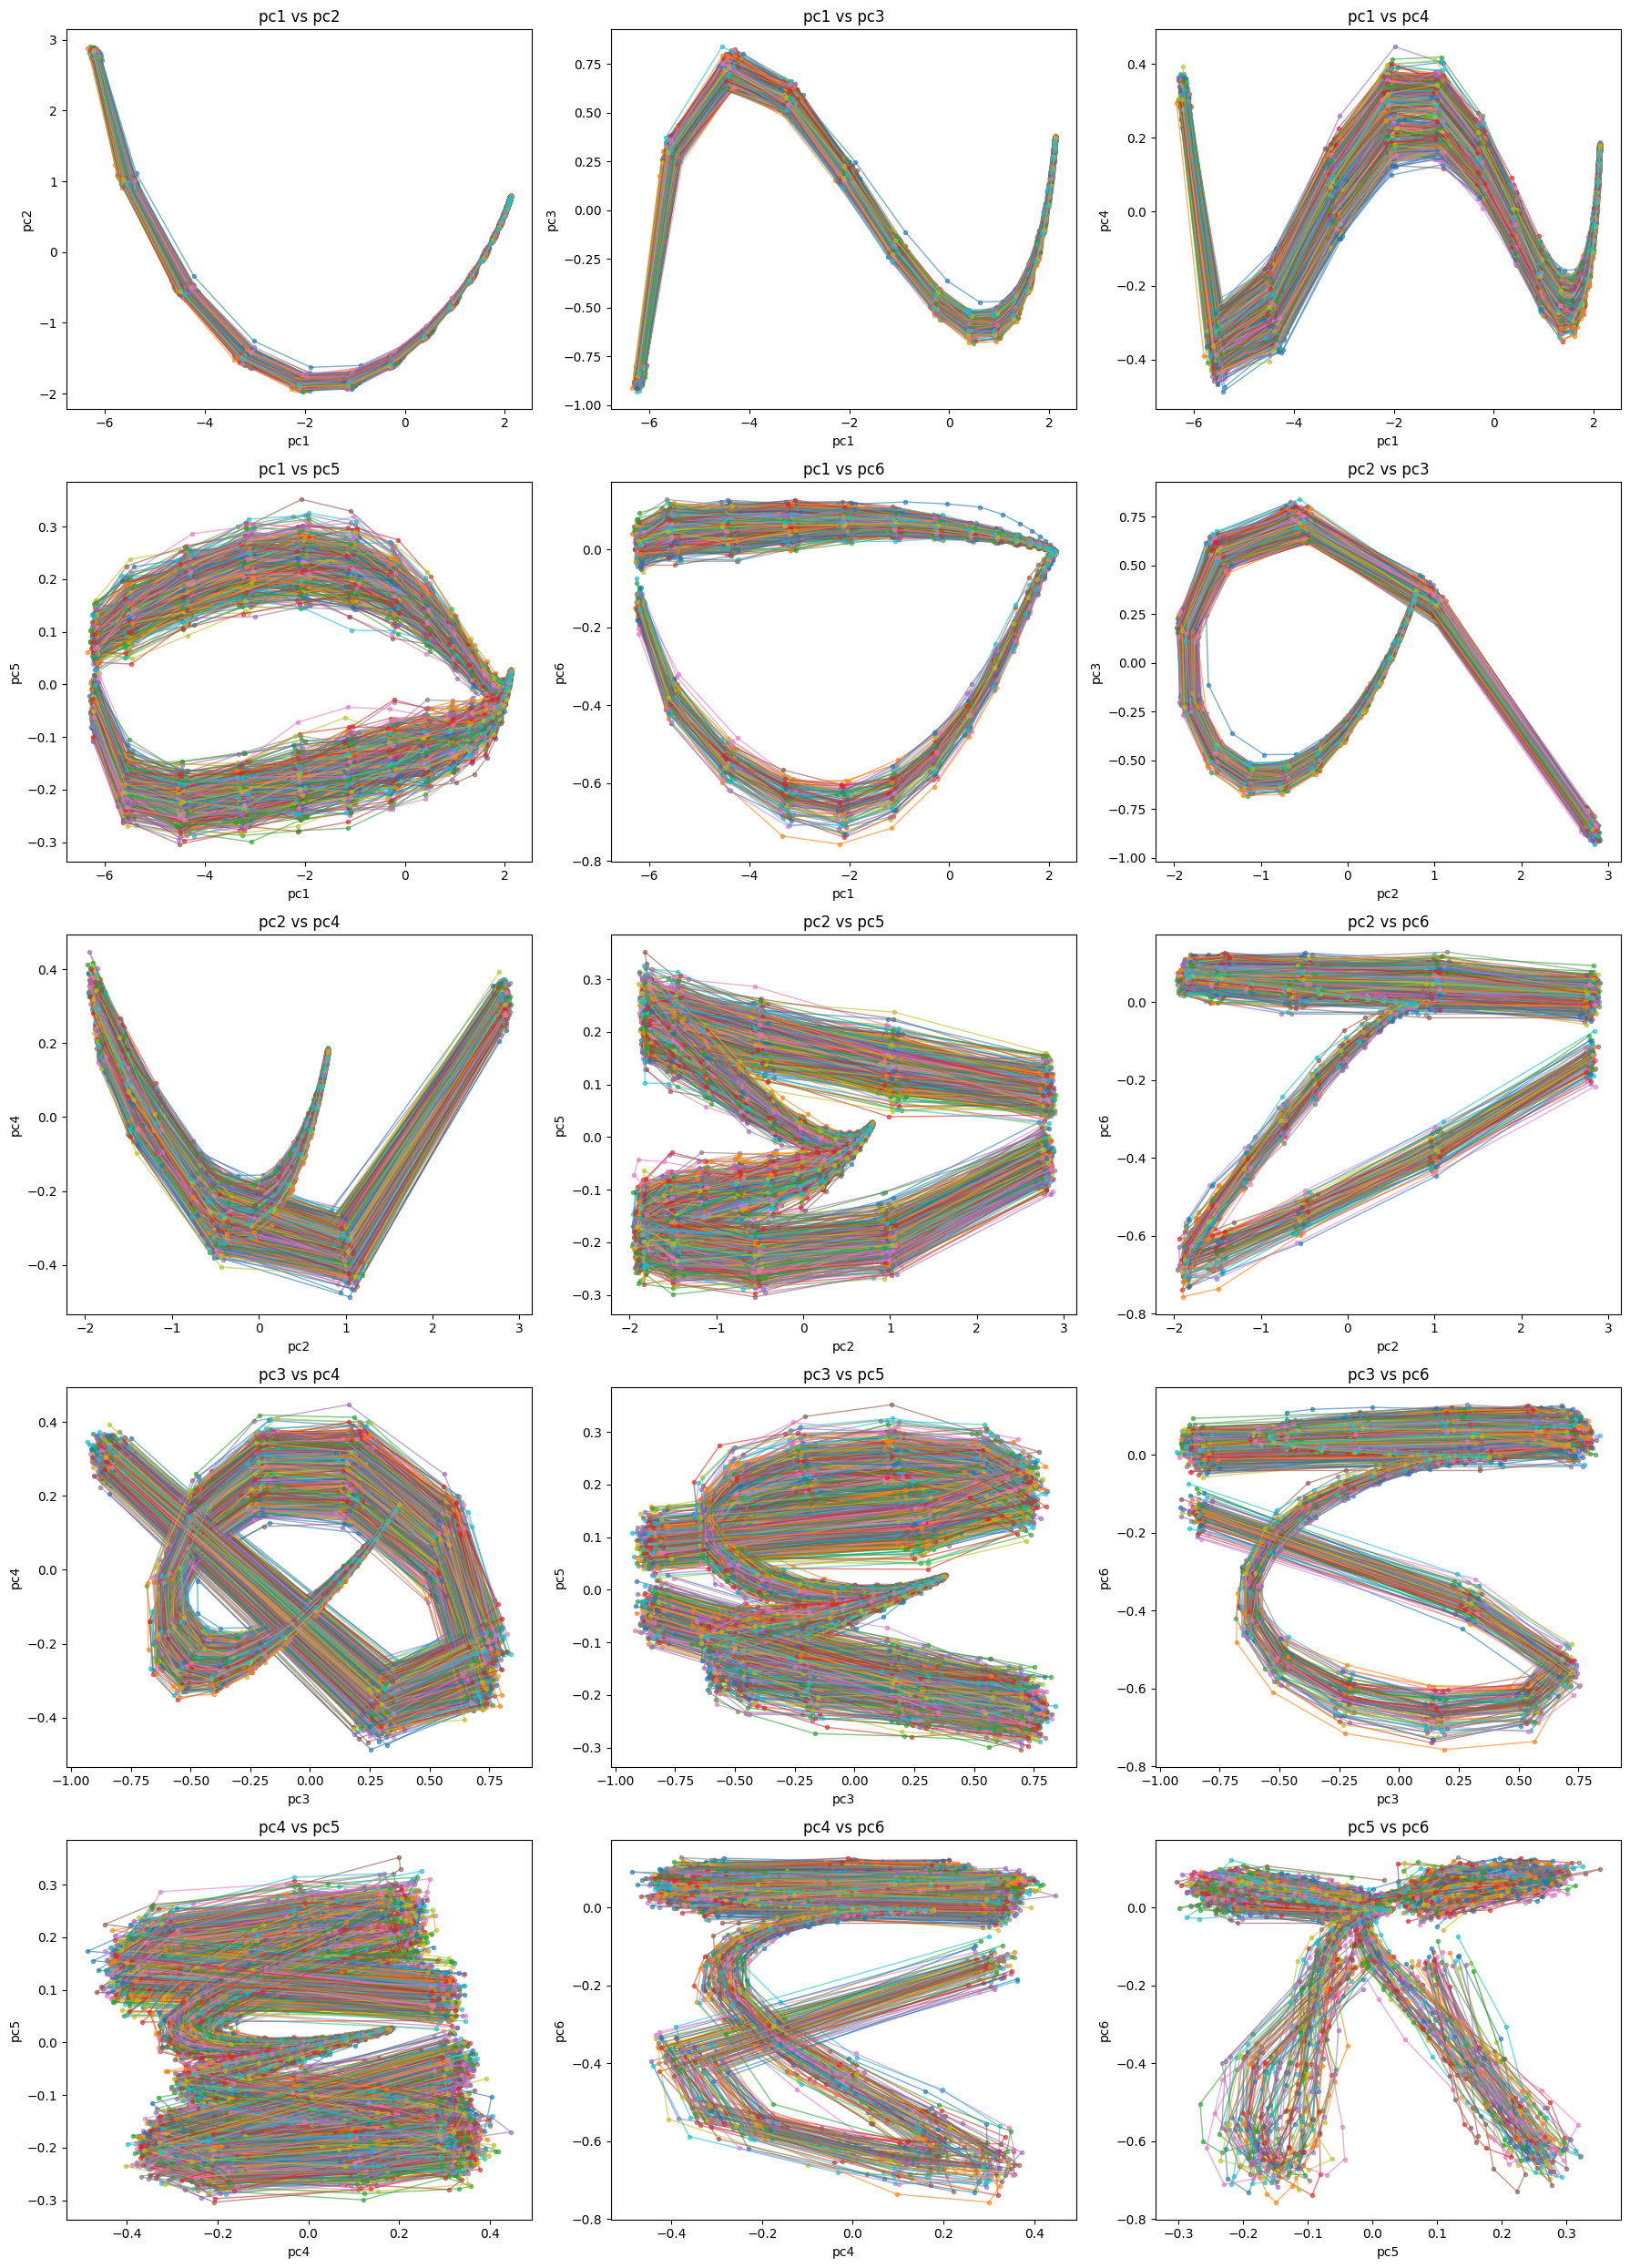

In [46]:

from itertools import combinations

pcs = ['pc1', 'pc2', 'pc3', 'pc4', 'pc5', 'pc6']
pc_pairs = list(combinations(pcs, 2))

n_cols = 3
n_rows = -(-len(pc_pairs) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, (ax, (x_col, y_col)) in enumerate(zip(axes, pc_pairs)):
    for model_id, group in pca_traj.groupby('model_id'):
        ax.plot(group[x_col], group[y_col], marker='o', linewidth=1, markersize=3, alpha=0.6, label=model_id)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')

# Hide unused axes
for ax in axes[len(pc_pairs):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## Step 4: Model Clustering

Clustering reveals distinct groups within the model ensemble. In this example, we found 2 major clusters corresponding to different attractor groups, representing distinct cellular fate decisions.

  0%|          | 0/9 [00:00<?, ?it/s]

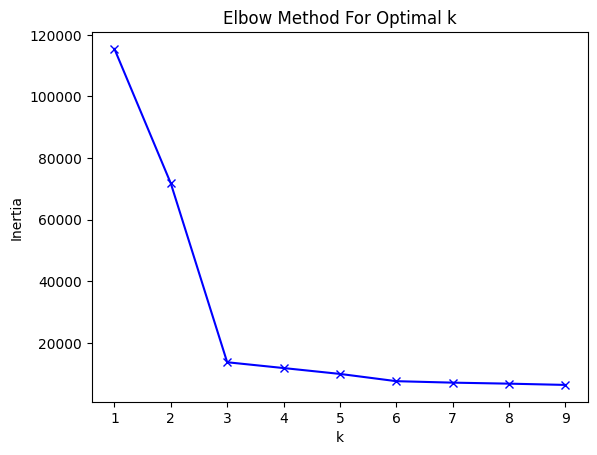

In [12]:
model.trajectory.cluster_elbow_plot(n_cluster=10)

In [13]:
model.trajectory.calculate_kmean_cluster(n_cluster=3, random_state=12345)

Calculated k-means clustering with 3 clusters.


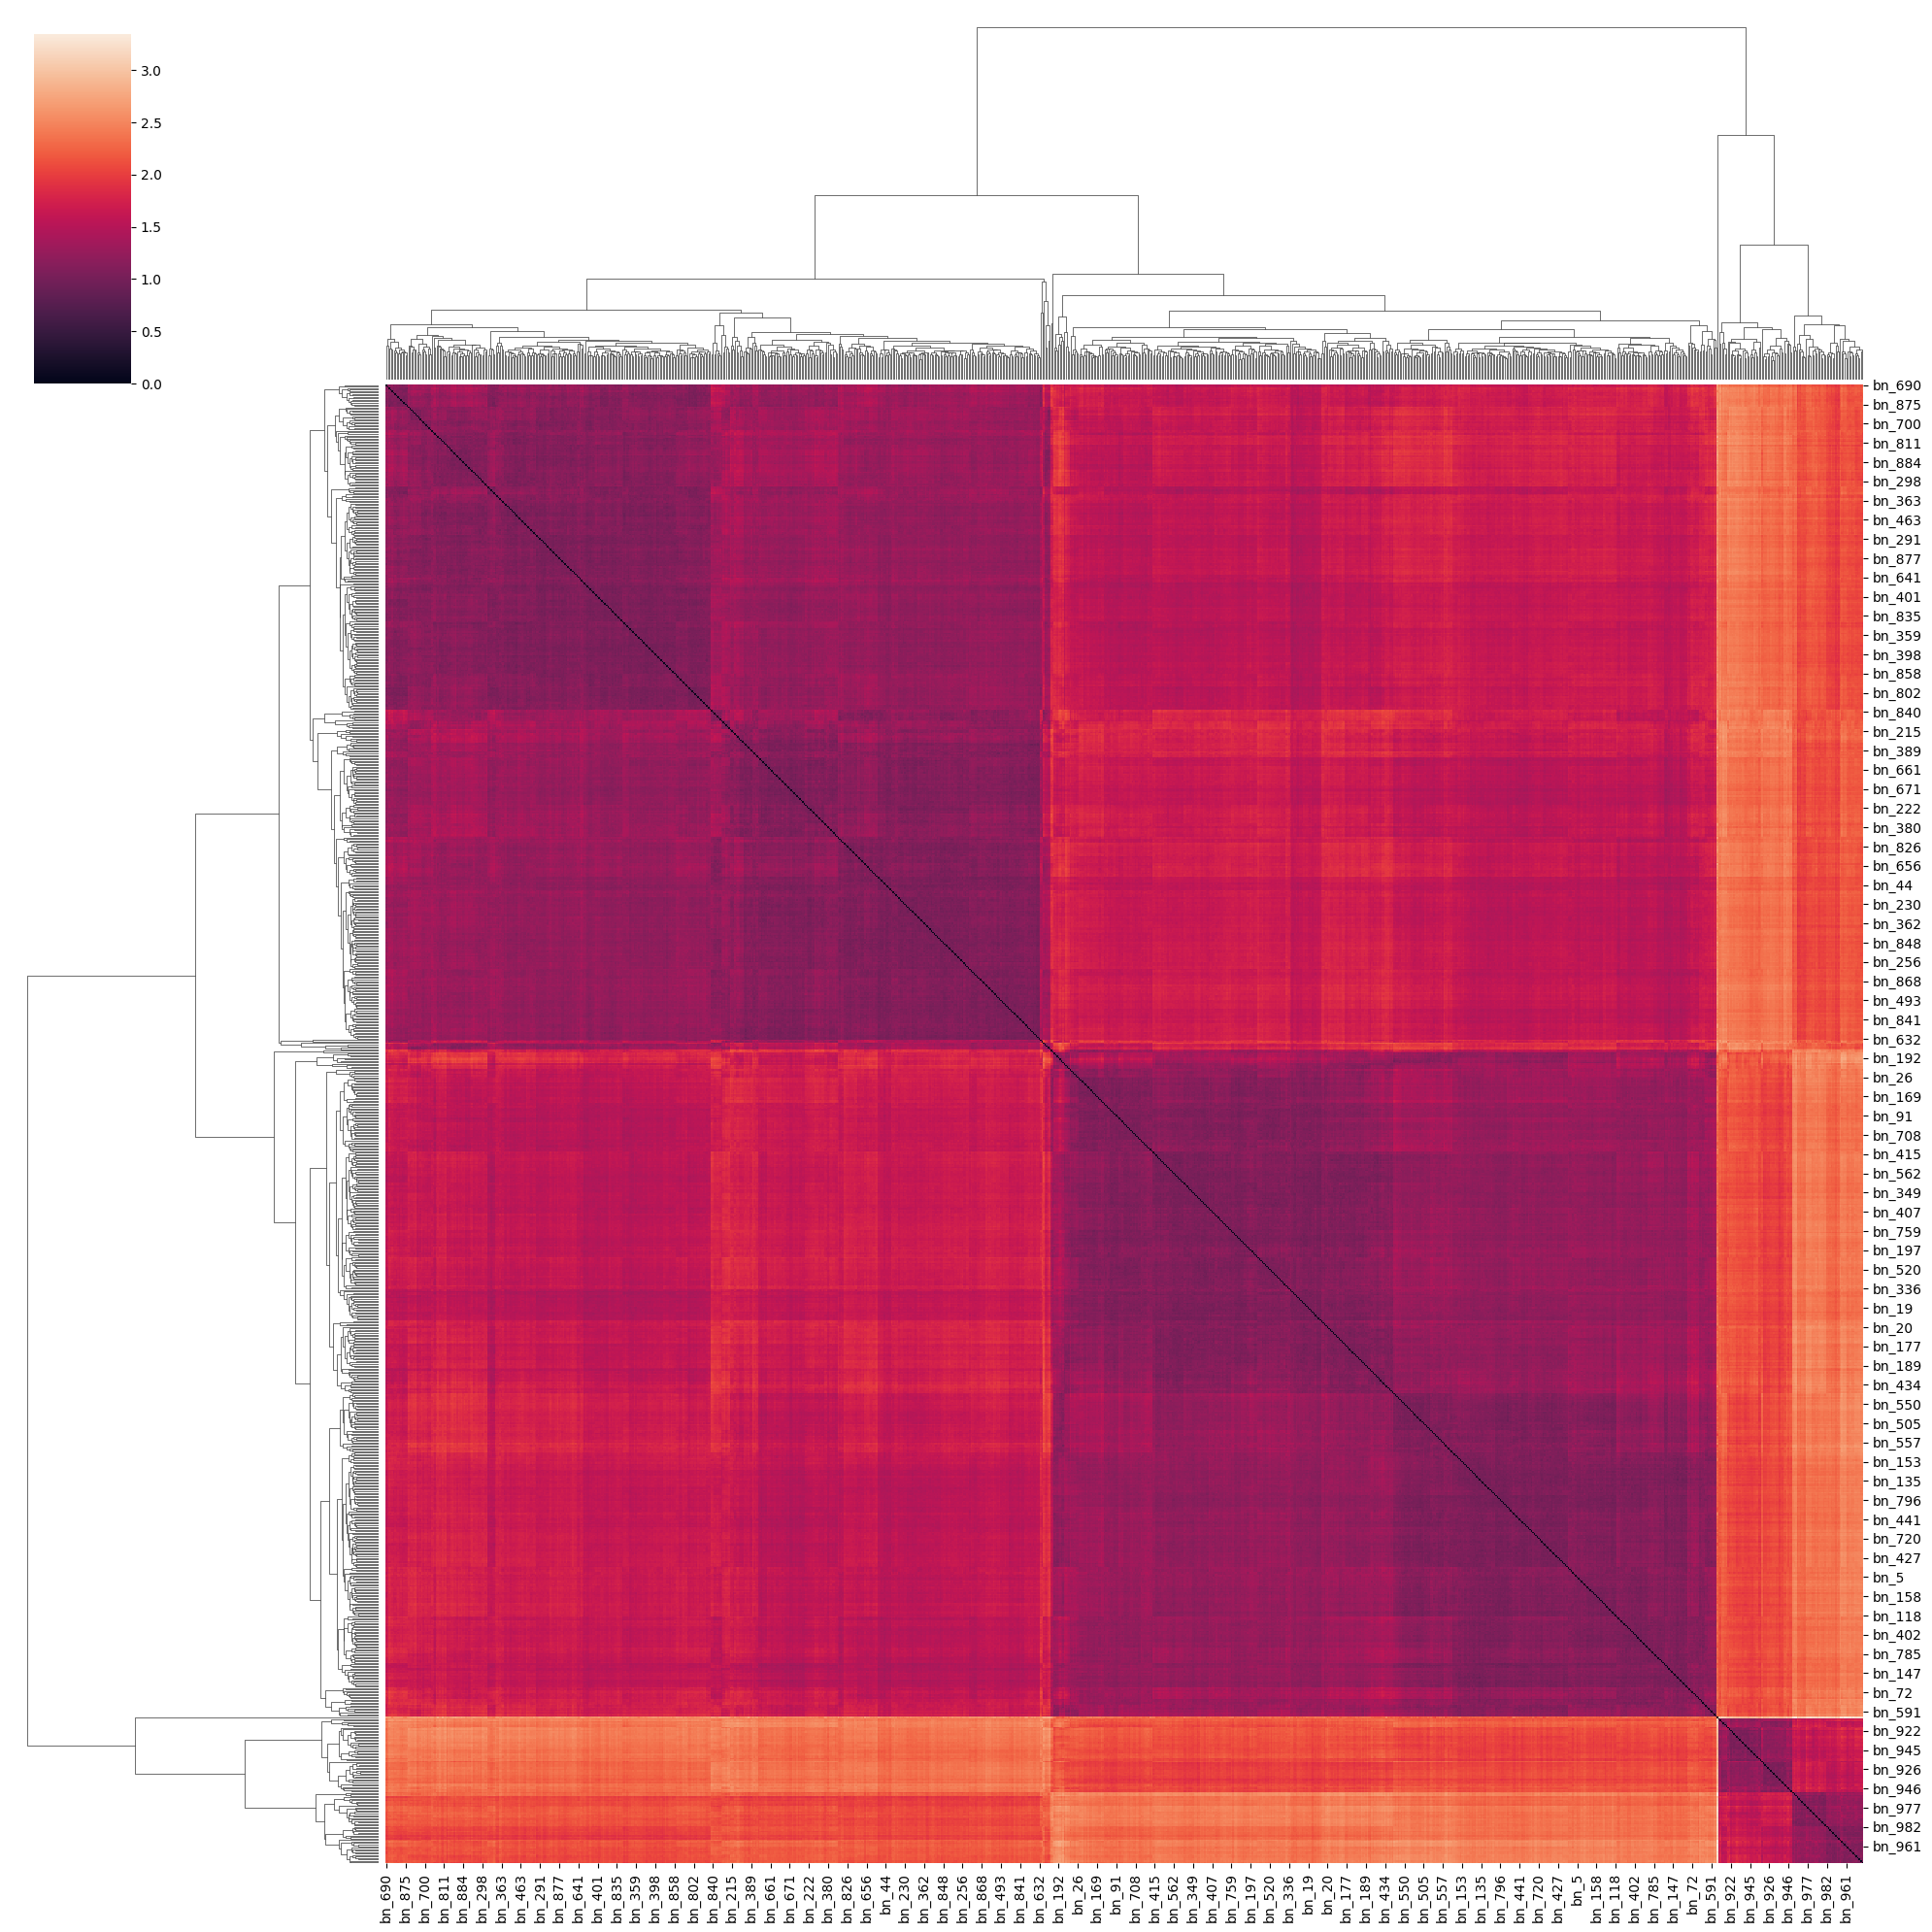

In [47]:
distance_matrix = model.trajectory.distance_matrix

sns.clustermap(distance_matrix, figsize=(20, 20))

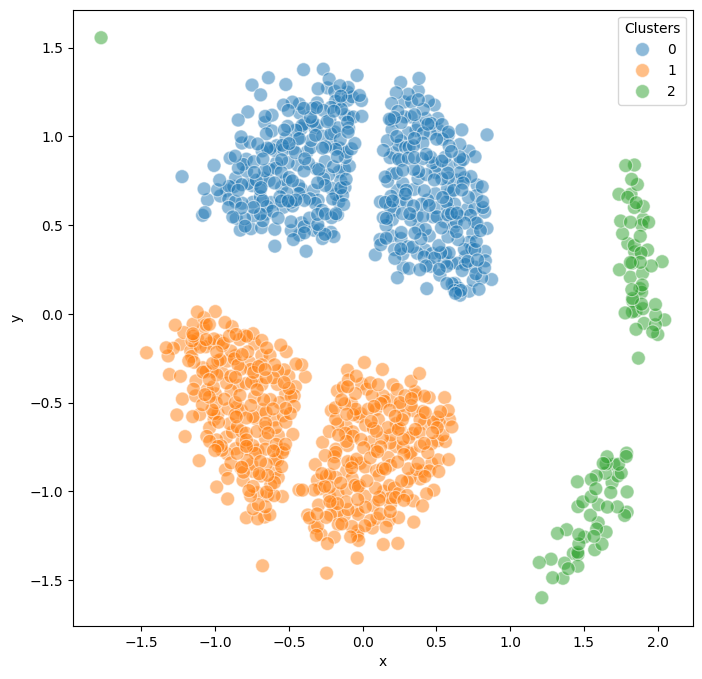

In [14]:
model.trajectory.plot_MDS(s = 100, fig_size = (8,8),plot_cluster = True, save_fig = True)

## Step 5: Logic Function Analysis

This step implements the **logical function evaluation** component of AstroLogics:

- Converts Boolean equations to Disjunctive Normal Form (DNF)
- Creates feature matrices comparing logical rules across models
- Identifies **constant**, **varied**, and **marker** clauses

In [21]:
model.create_logic()
model.logic.model_logic
model.logic.create_flattend_logic_clause()

Loading models logics


  0%|          | 0/1000 [00:00<?, ?it/s]

Concatenate results into matrix


  0%|          | 0/1000 [00:00<?, ?it/s]

Logic object created
Flatten models logic clauses


  0%|          | 0/1000 [00:00<?, ?it/s]

Concatenate results into matrix


  0%|          | 0/1000 [00:00<?, ?it/s]

Flattend logic clause created


## Step 6: Calculate statistics of logic features (clauses)

In this step, we have already featurized the logical equations into model logic features (clauses).

We can then integrate the clusters obtained from trajectory analysis into `.logic` and perform a chi-square statistical test to categorize logic features (clauses) into three major groups:

- Constant: Core regulatory features that appear across BNs in the model ensemble
- Varied: Features that may differ between individual BNs but show no statistical significance
- Marker: Key discriminatory features that statistically distinguish between different model clusters

We can define the p-value threshold for the chi-square test using the `pval_threshold` parameter.


In [22]:
model.logic.map_model_clusters(model.trajectory.cluster_dict)
model.logic.calculate_logic_statistic(pval_threshold = 0.0001)

Model clusters mapped to logic clauses


The results of the analysis can be visualized in the Manhattan plot shown below.

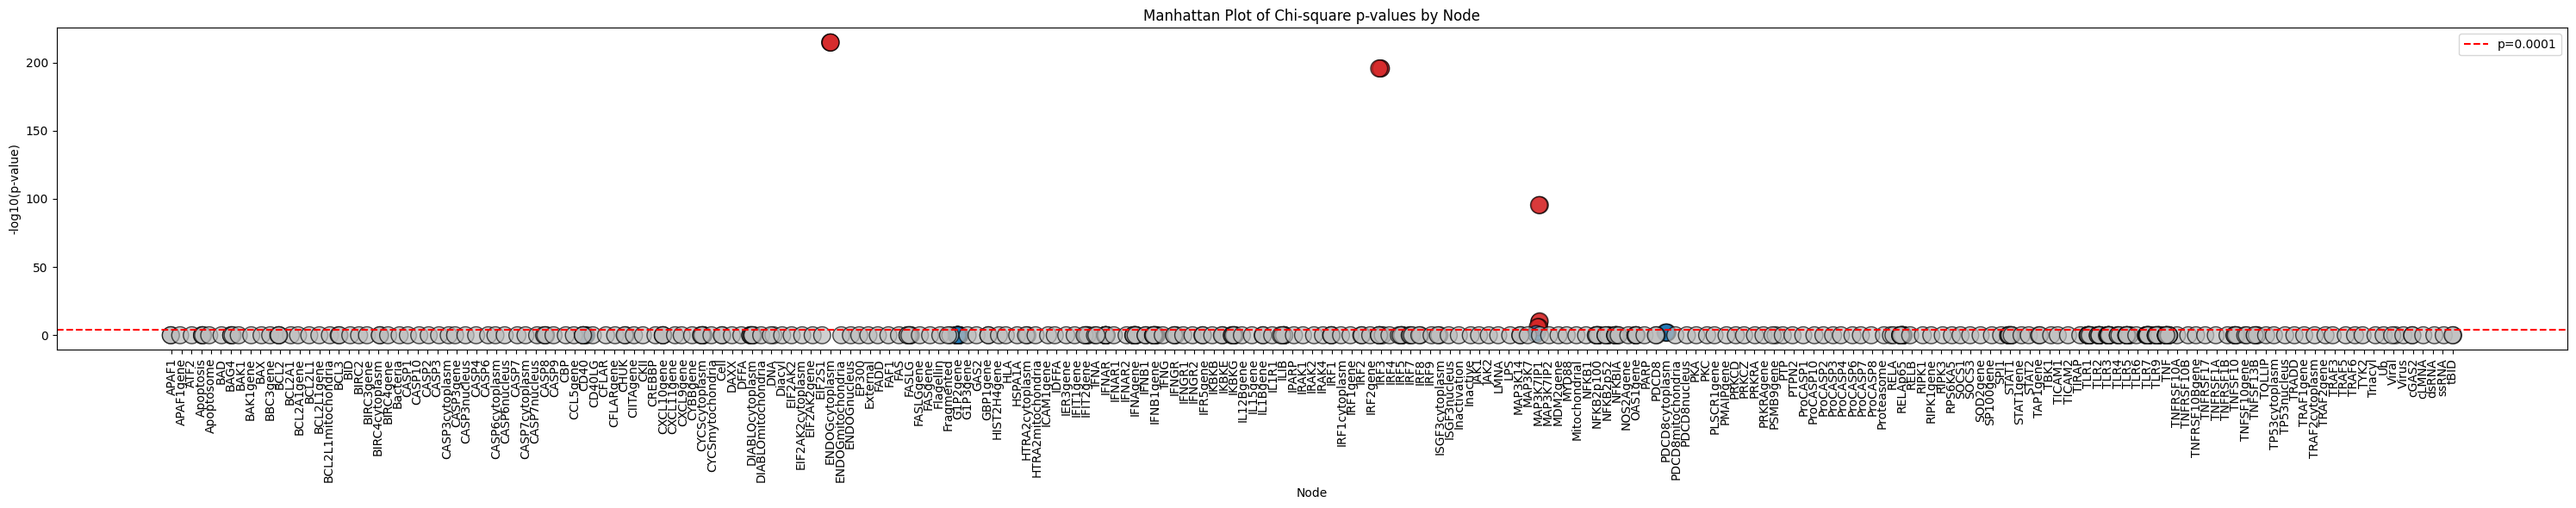

In [36]:
model.logic.plot_manhattan(fig_size=(30, 6))

Or the results can be summarized in the bar plot shown here.

To get an overview of the process, we can plot a heatmap of the logical rules to see how logical features differ across model groups.

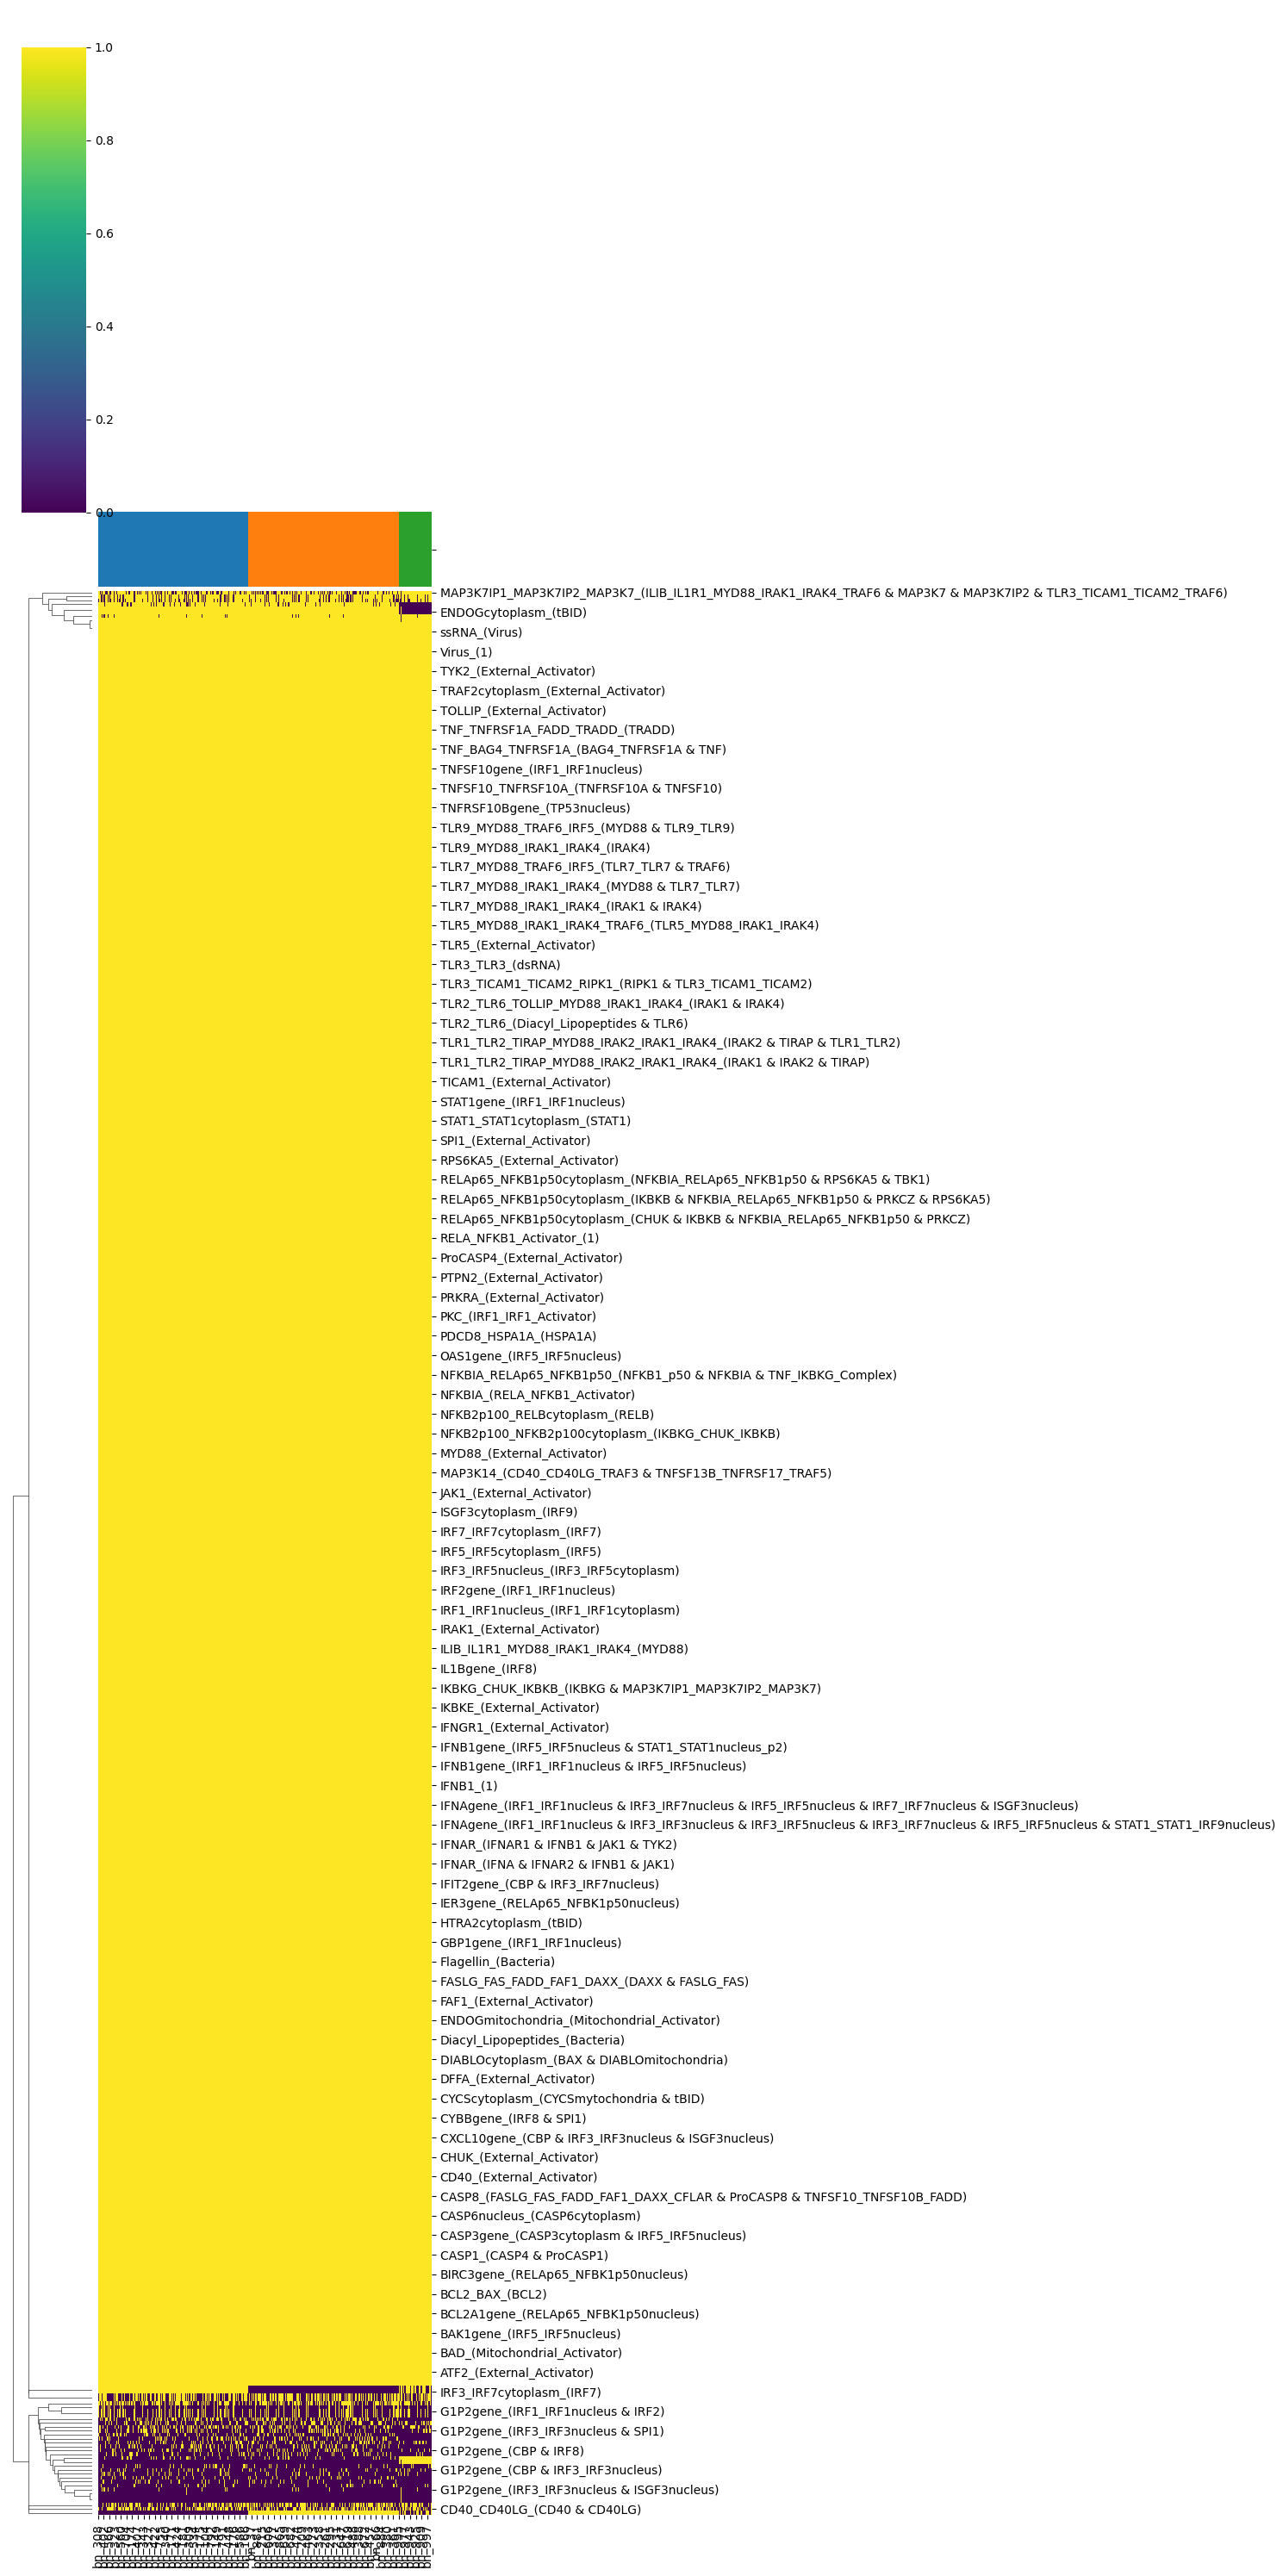

In [25]:
logic_feature = model.logic.logic_clause_flattend
cluster_dict = model.trajectory.cluster_dict

# Map the cluster labels to the columns of the logic_feature
column_clusters = pd.Series(cluster_dict).reindex(logic_feature.columns, fill_value=-1)
column_clusters = column_clusters.sort_values()

# Create a color palette for the clusters
unique_clusters = column_clusters.unique()
palette = sns.color_palette("tab10", len(unique_clusters))
column_colors = column_clusters.map(dict(zip(unique_clusters, palette)))

# Create the clustermap
sns.clustermap(logic_feature[column_clusters.index], cmap='viridis', figsize=(15, 30), 
               row_cluster=True, col_cluster=False, col_colors=column_colors)
plt.show()

## Step 8: Advanced Trajectory Analysis

These visualizations help identify:

- **Most variable nodes**: Components showing the greatest differences between models
- **Critical regulators**: Nodes whose activity patterns distinguish model clusters
- **Temporal patterns**: How specific nodes behave over simulation time

In this first plot, we check which features show the highest variance in their dynamics across the simulation. We calculate the variance of node activation probabilities for all BNs in the model ensemble across all timepoints and plot the results as a heatmap.

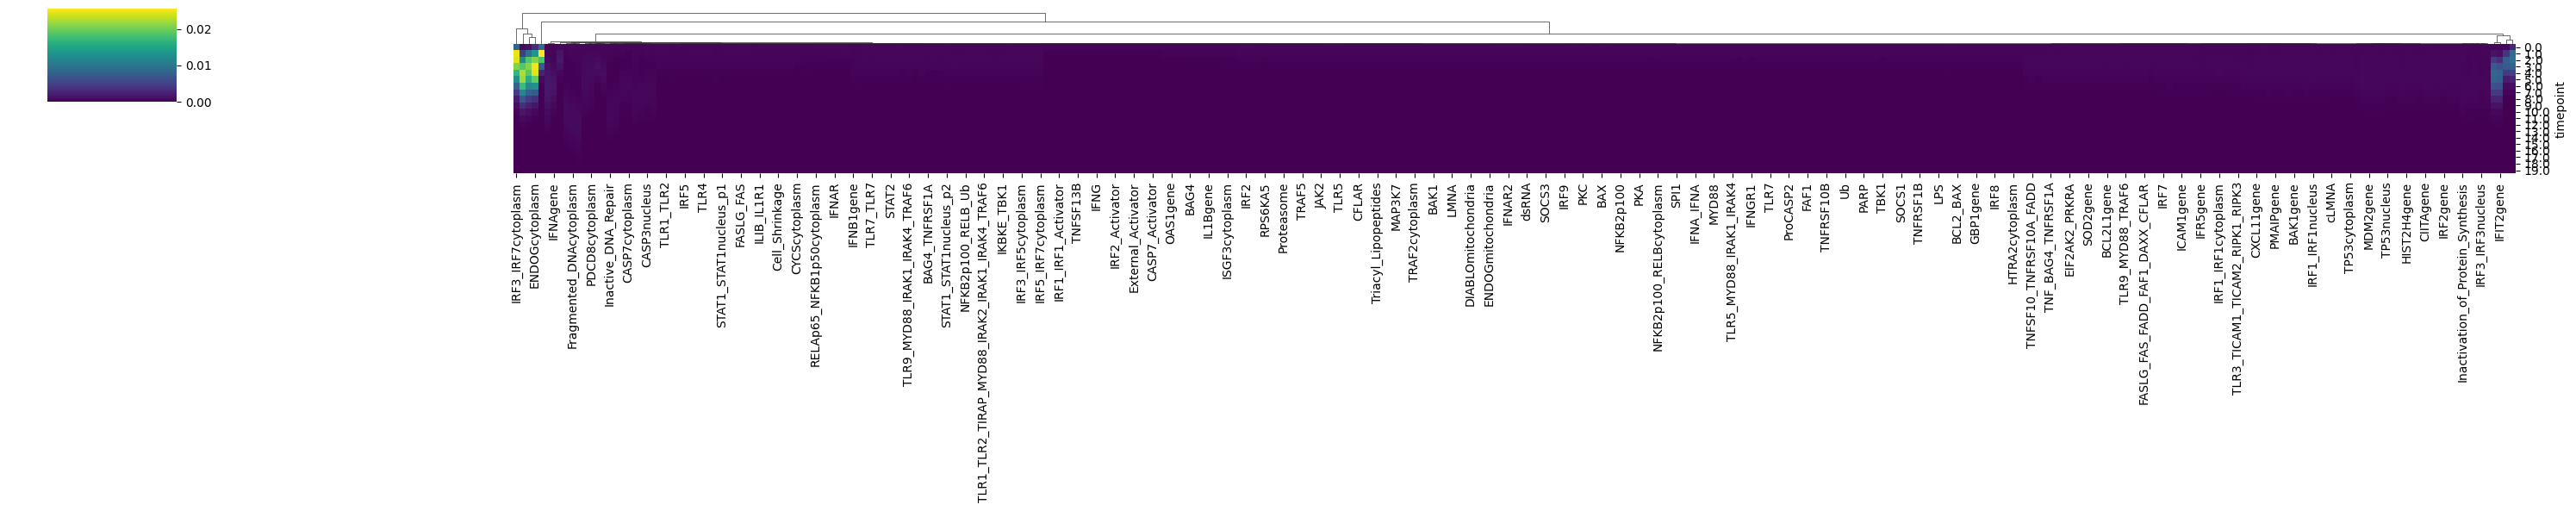

In [29]:
variance = model.trajectory.plot_trajectory_variance(fig_size=(30, 6))


We identify key nodes of interest (GF, EMT, and AKT2), which show high variance across timepoints.
Finally, we can visualize the dynamics of these nodes between the two identified clusters using line plots.

From this, we found that these node dynamics differ during early simulation timepoints, while later converging toward stable values.

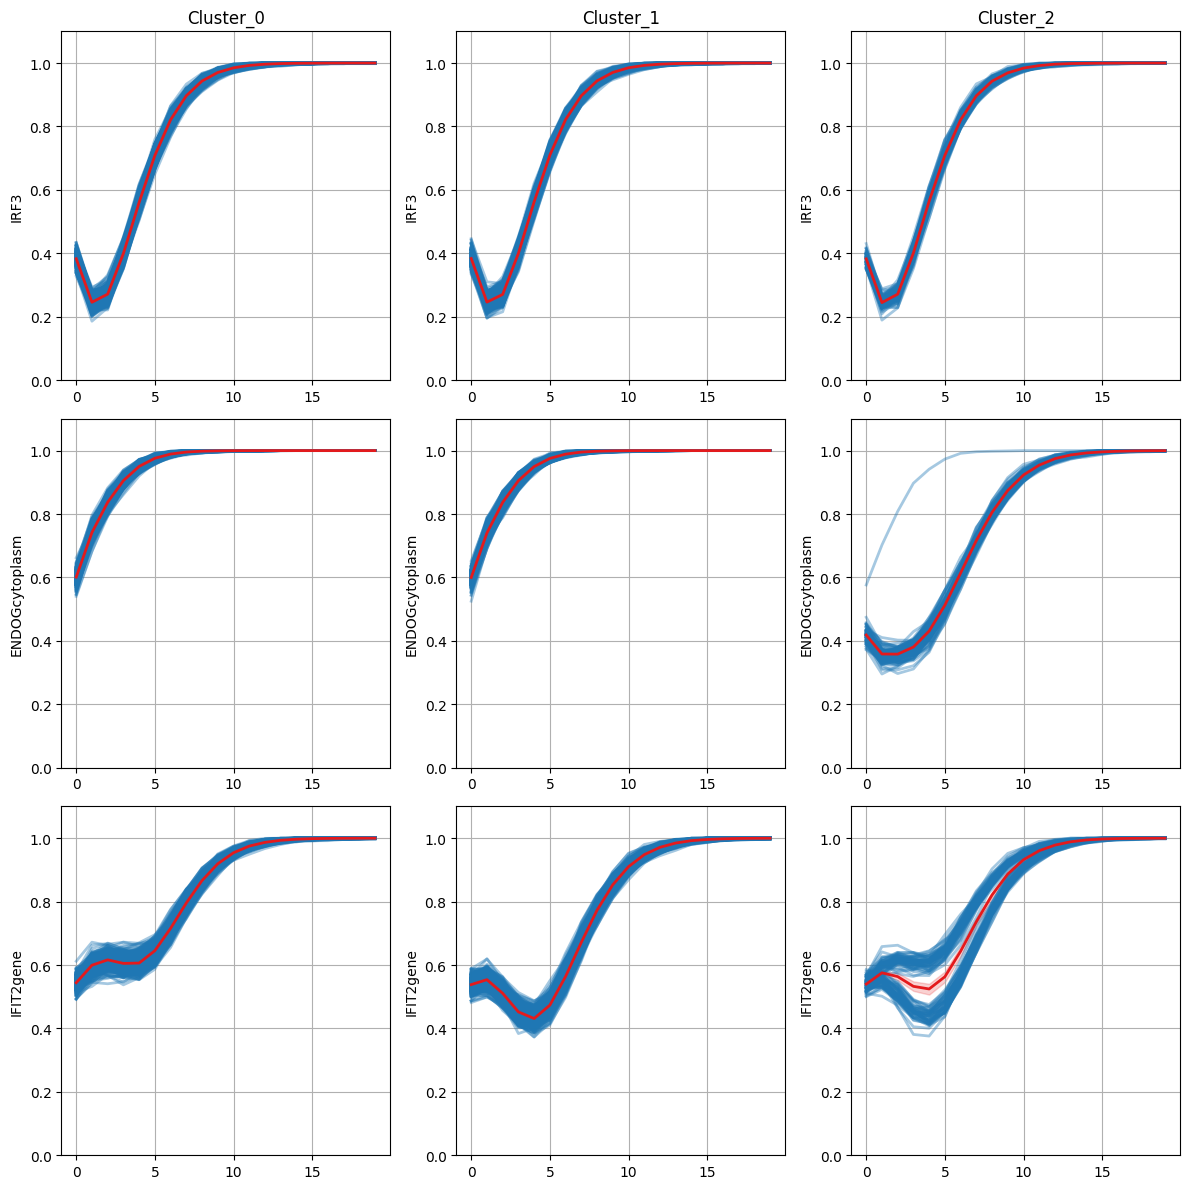

In [40]:
model.trajectory.plot_node_trajectory(node = ['IRF3', 'ENDOGcytoplasm', 'IFIT2gene'],
                                      fig_width = 4, fig_height=4)

## Step 9: Logic Feature Heatmap

This analysis typically reveals that **GF** is a key distinguishing node between clusters, with different regulatory logic patterns across clusters.

<Figure size 800x800 with 0 Axes>

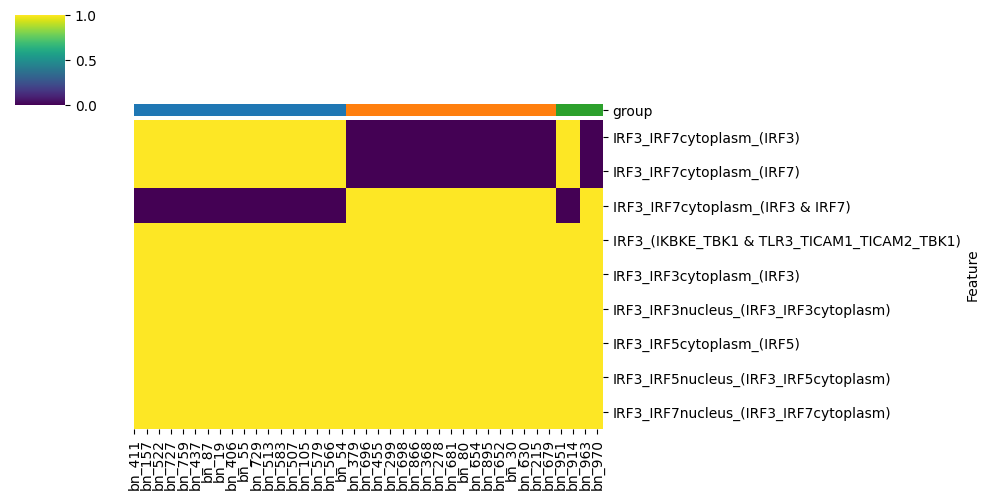

In [39]:
model.logic.plot_node_logic_heatmap(node = ['IRF3'],
                                     fig_size = (8, 8))